In [1]:
from google.colab import files
uploaded = files.upload()

Saving PeCan_sample_info_20260312.xlsx to PeCan_sample_info_20260312.xlsx


In [2]:
import pandas as pd

filename = "PeCan_sample_info_20260312.xlsx"
df = pd.read_excel(filename)

print(df.head())

       sample_name subject_name subtype_root diagnosis_subtype_code  \
0  SJADMA091139_D1     SJ091139  Brain Tumor                   ACPG   
1  SJADMA091186_D1     SJ091186  Brain Tumor                   ACPG   
2  SJADMA091207_D1     SJ091207  Brain Tumor                   ACPG   
3  SJADMA091220_D1     SJ091220  Brain Tumor                   ACPG   
4  SJADMA091295_D1     SJ091295  Brain Tumor                   ACPG   

               diagnosis_subtype_name subtype_biomarkers age_at_diagnosis_yrs  \
0  Adamantinomatous Craniopharyngioma        CTNNB1 T41I        Not Available   
1  Adamantinomatous Craniopharyngioma        CTNNB1 S37C        Not Available   
2  Adamantinomatous Craniopharyngioma        CTNNB1 S33F        Not Available   
3  Adamantinomatous Craniopharyngioma        CTNNB1 D32Y        Not Available   
4  Adamantinomatous Craniopharyngioma   CTNNB1 S29_S33>N        Not Available   

  age_at_sample_collection_yrs            sex           race      ethnicity  \
0      

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Clean age column
df["age_at_diagnosis_yrs"] = pd.to_numeric(df["age_at_diagnosis_yrs"], errors="coerce")

# Remove missing ages
df_clean = df.dropna(subset=["age_at_diagnosis_yrs"])

# Top cancers
top_cancers = (
    df_clean["diagnosis_subtype_name"]
    .value_counts()
    .head(10)
    .index
)

print("Top cancers:")
print(top_cancers)

Top cancers:
Index(['Neuroblastoma',
       'B-Cell Acute Lymphoblastic Leukemia/Lymphoma with Hyperdiploidy',
       'B-Cell Acute Lymphoblastic Leukemia/Lymphoma with ETV6::RUNX1 Fusion',
       'Medulloblastoma, non-WNT/non-SHH', 'Pilocytic Astrocytoma',
       'Osteosarcoma', 'Posterior Fossa Ependymoma', 'Retinoblastoma',
       'Wilms Tumor', 'Diffuse Midline Glioma, H3 K27-altered'],
      dtype='object', name='diagnosis_subtype_name')


/tmp/ipykernel_382/3557929098.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["age_group"] = pd.cut(


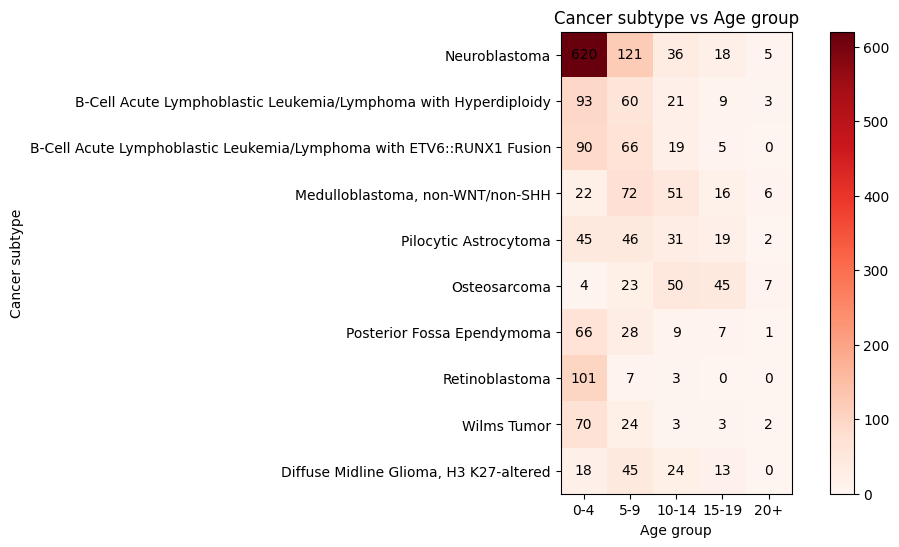

In [4]:
age_bins = [0,4,9,14,19,100]
age_labels = ["0-4","5-9","10-14","15-19","20+"]

df_clean["age_group"] = pd.cut(
    df_clean["age_at_diagnosis_yrs"],
    bins=age_bins,
    labels=age_labels
)

heatmap_data = pd.crosstab(
    df_clean["diagnosis_subtype_name"],
    df_clean["age_group"]
)

heatmap_data = heatmap_data.loc[top_cancers]

plt.figure(figsize=(10,6))
plt.imshow(heatmap_data, cmap="Reds")

plt.xticks(range(len(age_labels)), age_labels)
plt.yticks(range(len(top_cancers)), top_cancers)

for i in range(len(top_cancers)):
    for j in range(len(age_labels)):
        value = heatmap_data.iloc[i,j]
        plt.text(j, i, value, ha="center", va="center")

plt.title("Cancer subtype vs Age group")
plt.xlabel("Age group")
plt.ylabel("Cancer subtype")

plt.colorbar()

plt.show()

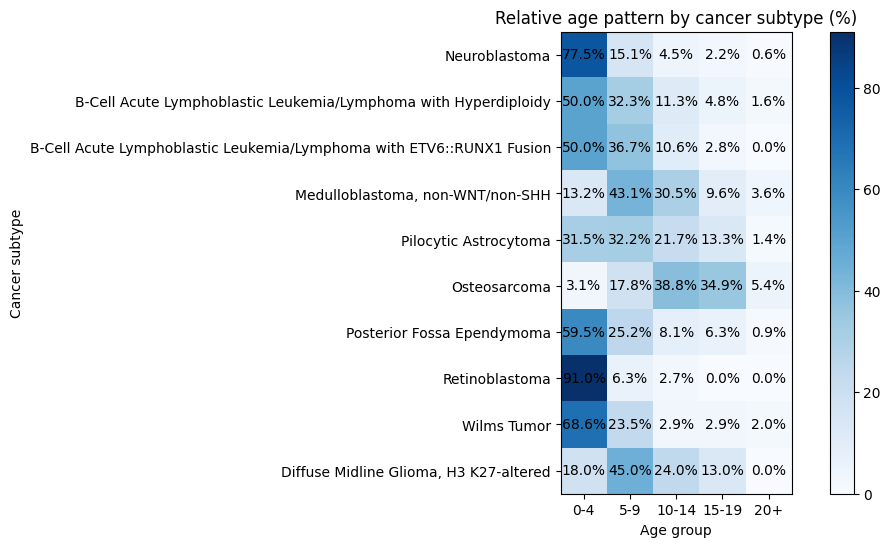

<Figure size 640x480 with 0 Axes>

In [5]:
percent_heatmap = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10,6))
plt.imshow(percent_heatmap, cmap="Blues")

plt.xticks(range(len(age_labels)), age_labels)
plt.yticks(range(len(top_cancers)), top_cancers)

for i in range(len(top_cancers)):
    for j in range(len(age_labels)):
        val = percent_heatmap.iloc[i,j]
        plt.text(j, i, f"{val:.1f}%", ha="center", va="center")

plt.title("Relative age pattern by cancer subtype (%)")
plt.xlabel("Age group")
plt.ylabel("Cancer subtype")

plt.colorbar()

plt.show()
plt.show()

plt.savefig("pediatric_cancer_age_heatmap.png", dpi=300, bbox_inches="tight")

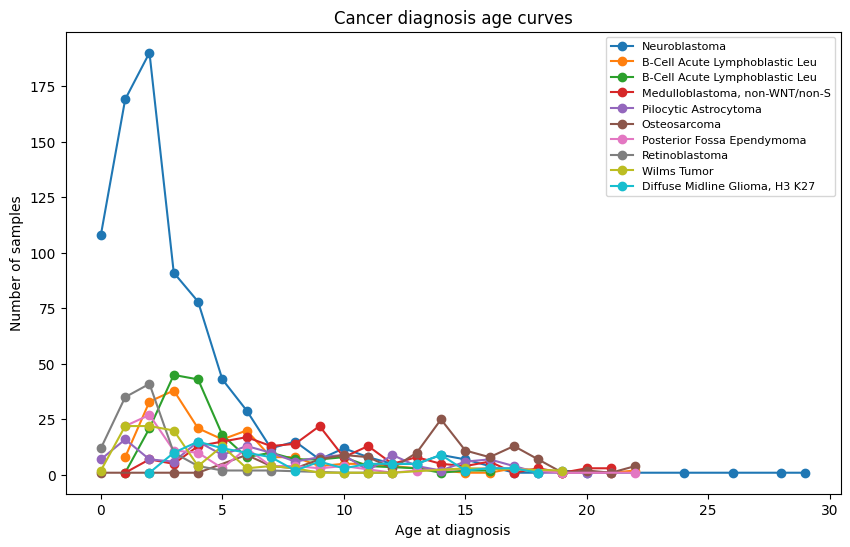

In [6]:
plt.figure(figsize=(10,6))

for cancer in top_cancers:

    subset = df_clean[df_clean["diagnosis_subtype_name"] == cancer]

    counts = (
        subset["age_at_diagnosis_yrs"]
        .round()
        .value_counts()
        .sort_index()
    )

    plt.plot(
        counts.index,
        counts.values,
        marker="o",
        label=cancer[:30]
    )

plt.xlabel("Age at diagnosis")
plt.ylabel("Number of samples")
plt.title("Cancer diagnosis age curves")

plt.legend(fontsize=8)

plt.show()

In [7]:
plt.figure(figsize=(12,8), dpi=300)

<Figure size 3600x2400 with 0 Axes>

<Figure size 3600x2400 with 0 Axes>

In [8]:
plt.savefig("pediatric_cancer_age_heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_382/2981959844.py:81: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


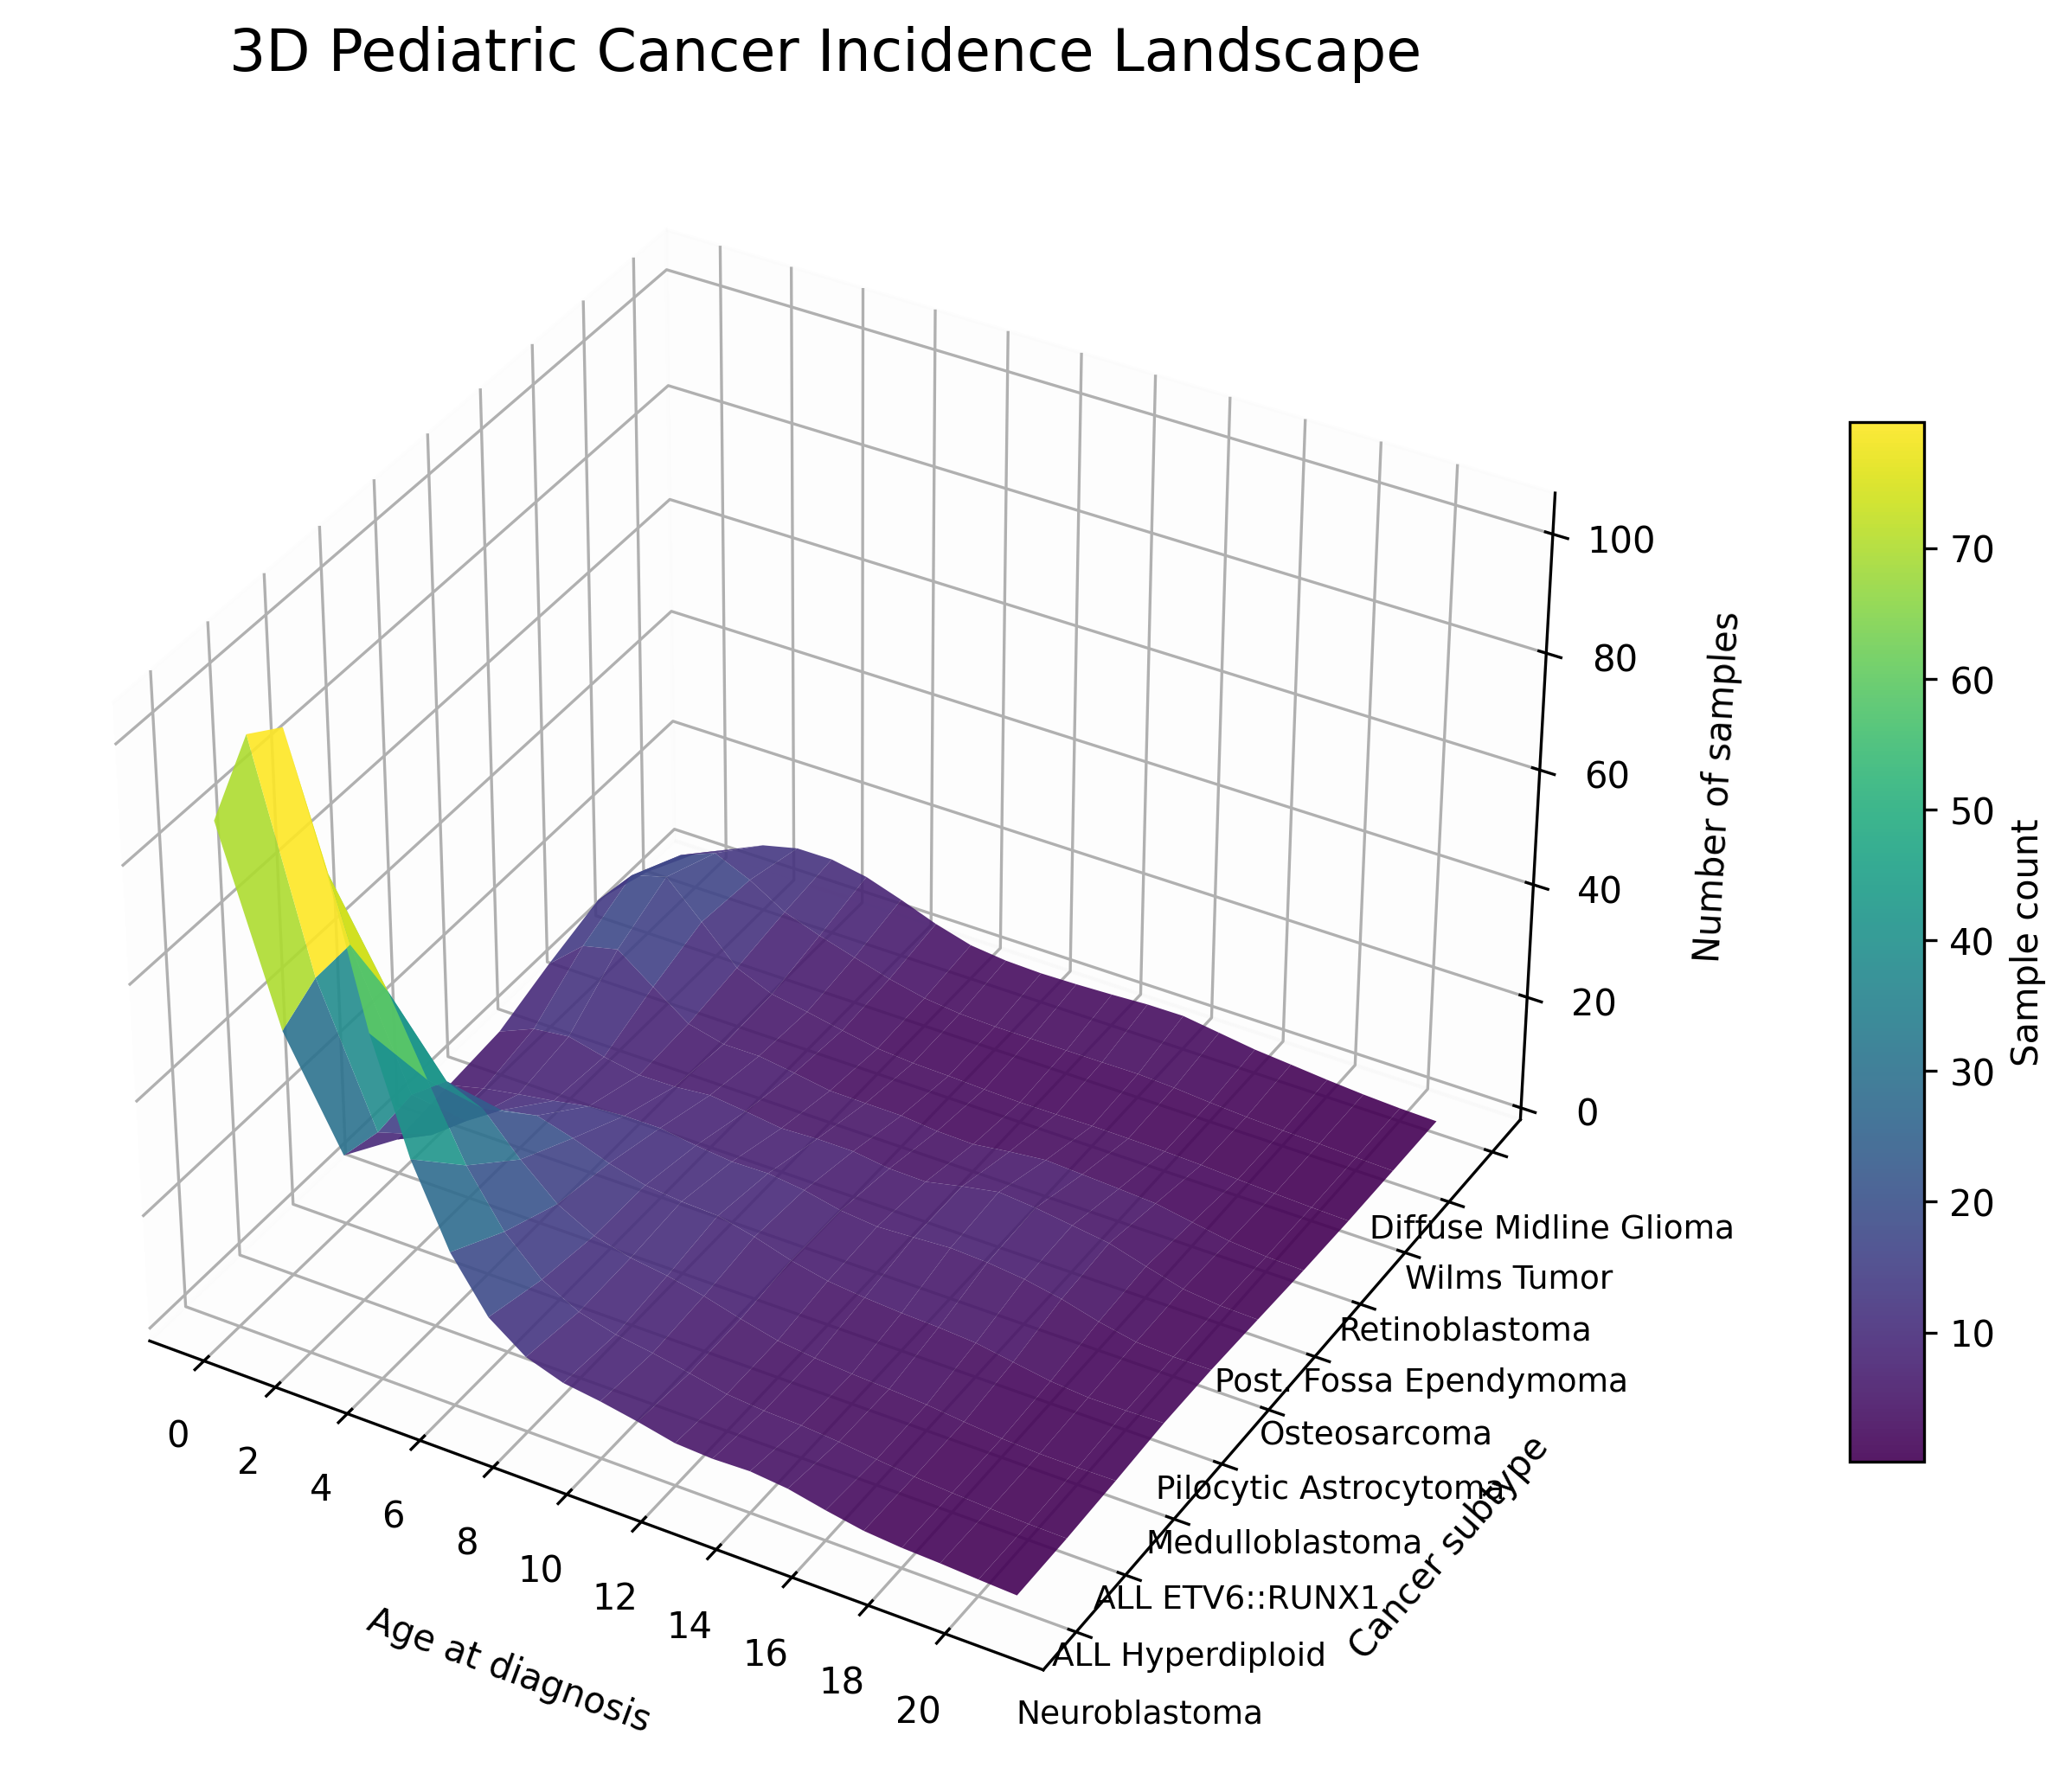

In [9]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

max_age = 21
x_ages = np.arange(0, max_age + 1)

landscape_matrix = []

for cancer in top_cancers:
    subset = df_clean[df_clean["diagnosis_subtype_name"] == cancer]

    counts = (
        subset["age_at_diagnosis_yrs"]
        .round()
        .astype(int)
        .value_counts()
        .sort_index()
    )

    y = np.zeros(max_age + 1)

    for age, count in counts.items():
        if 0 <= age <= max_age:
            y[age] = count

    landscape_matrix.append(y)

landscape_matrix = np.array(landscape_matrix)
smooth_matrix = gaussian_filter(landscape_matrix, sigma=1)

X, Y = np.meshgrid(x_ages, np.arange(len(top_cancers)))

short_labels = [
    "Neuroblastoma",
    "ALL Hyperdiploid",
    "ALL ETV6::RUNX1",
    "Medulloblastoma",
    "Pilocytic Astrocytoma",
    "Osteosarcoma",
    "Post. Fossa Ependymoma",
    "Retinoblastoma",
    "Wilms Tumor",
    "Diffuse Midline Glioma"
]

fig = plt.figure(figsize=(14, 8), dpi=300)
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X,
    Y,
    smooth_matrix,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9,
    antialiased=True
)

ax.set_title("3D Pediatric Cancer Incidence Landscape", pad=20, fontsize=16)
ax.set_xlabel("Age at diagnosis", labelpad=12)
ax.set_ylabel("Cancer subtype", labelpad=20)
ax.set_zlabel("Number of samples", labelpad=10)

ax.set_xticks(np.arange(0, max_age + 1, 2))
ax.set_yticks(np.arange(len(top_cancers)))
ax.set_yticklabels(short_labels, fontsize=9)
ax.tick_params(axis="y", pad=8)

ax.view_init(elev=35, azim=-60)

# Light pane color for cleaner look
ax.xaxis.pane.set_alpha(0.08)
ax.yaxis.pane.set_alpha(0.08)
ax.zaxis.pane.set_alpha(0.08)

cbar = fig.colorbar(surf, shrink=0.65, aspect=14, pad=0.08)
cbar.set_label("Sample count")

plt.tight_layout()
plt.savefig("pediatric_cancer_landscape_clean.png", dpi=300, bbox_inches="tight")
plt.show()

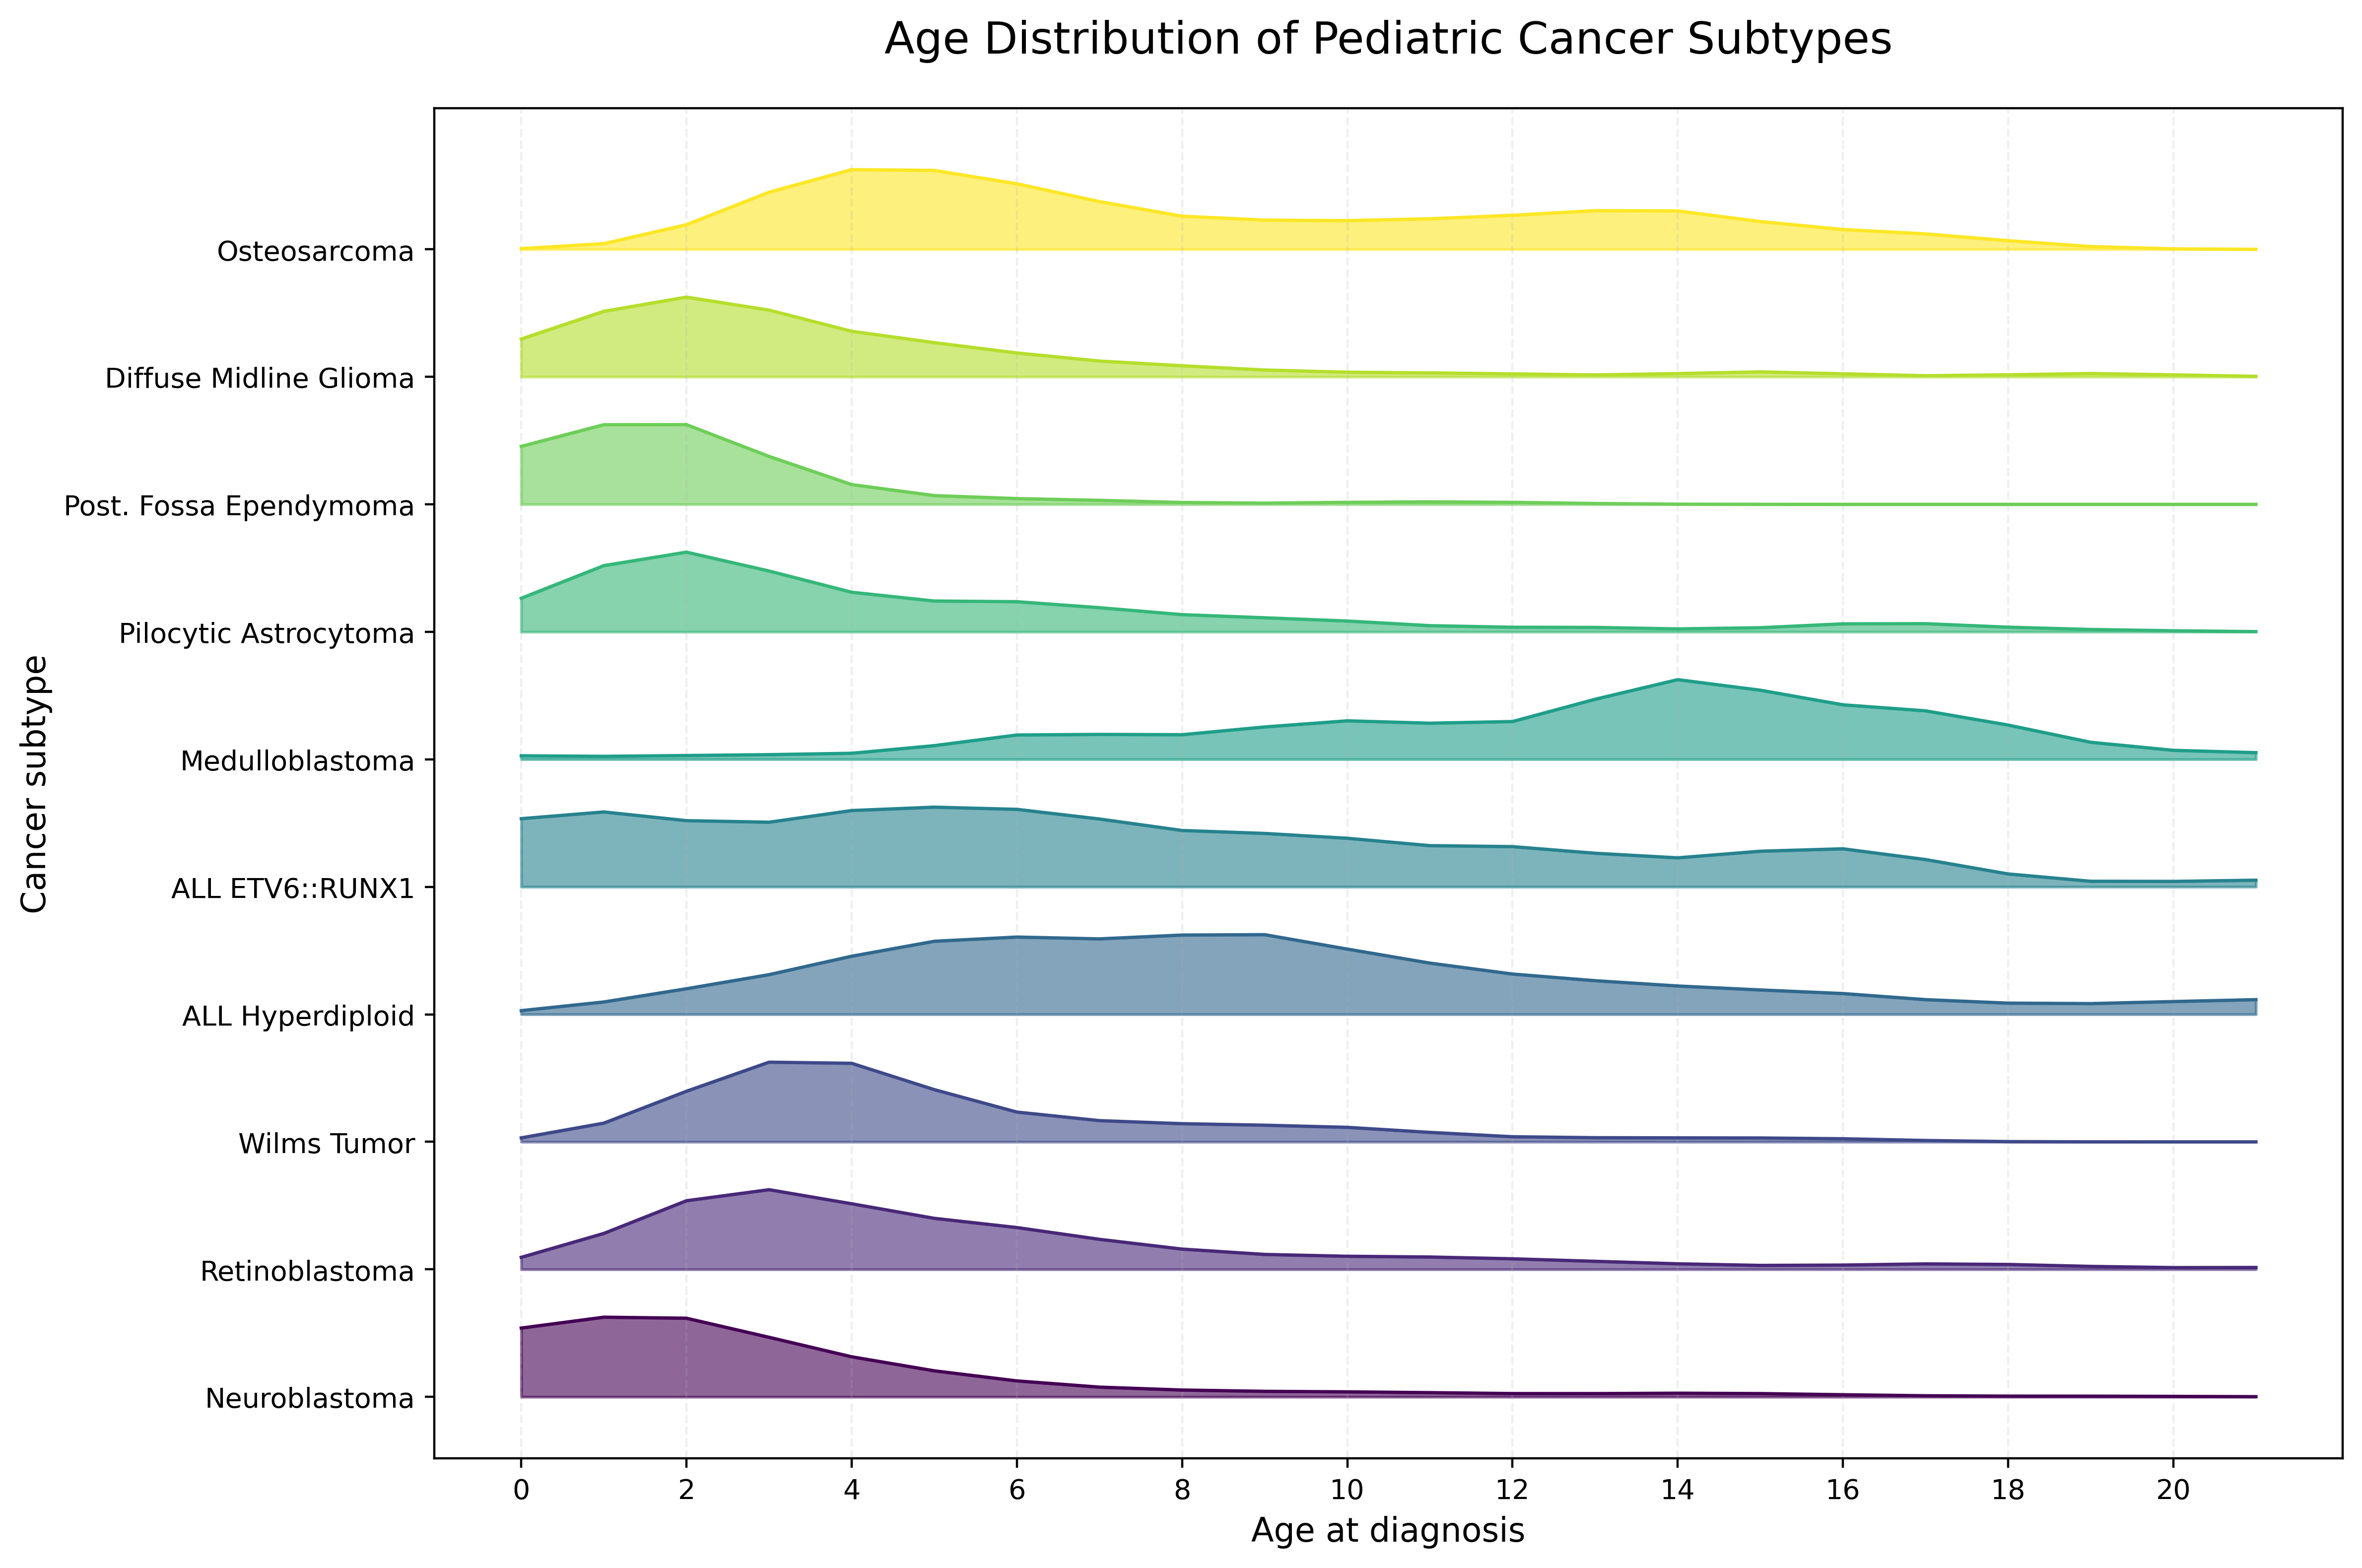

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

max_age = 21
x = np.arange(0, max_age + 1)

spacing = 1.6

short_labels = [
    "Neuroblastoma",
    "Retinoblastoma",
    "Wilms Tumor",
    "ALL Hyperdiploid",
    "ALL ETV6::RUNX1",
    "Medulloblastoma",
    "Pilocytic Astrocytoma",
    "Post. Fossa Ependymoma",
    "Diffuse Midline Glioma",
    "Osteosarcoma"
]

colors = plt.cm.viridis(np.linspace(0,1,len(top_cancers)))

fig, ax = plt.subplots(figsize=(12,8), dpi=400)

for i, cancer in enumerate(top_cancers):

    subset = df_clean[df_clean["diagnosis_subtype_name"] == cancer]

    counts = (
        subset["age_at_diagnosis_yrs"]
        .round()
        .astype(int)
        .value_counts()
        .sort_index()
    )

    y = np.zeros(max_age + 1)

    for age, count in counts.items():
        if 0 <= age <= max_age:
            y[age] = count

    y_smooth = gaussian_filter1d(y, sigma=1)

    if y_smooth.max() > 0:
        y_scaled = y_smooth / y_smooth.max()
    else:
        y_scaled = y_smooth

    ax.fill_between(
        x,
        i * spacing,
        y_scaled + i * spacing,
        color=colors[i],
        alpha=0.6
    )

    ax.plot(
        x,
        y_scaled + i * spacing,
        color=colors[i],
        linewidth=1.2
    )

ax.set_yticks(np.arange(len(short_labels)) * spacing)
ax.set_yticklabels(short_labels)

ax.set_xticks(np.arange(0, max_age + 1, 2))

ax.set_xlabel("Age at diagnosis", fontsize=12)
ax.set_ylabel("Cancer subtype", fontsize=12)

ax.set_title(
    "Age Distribution of Pediatric Cancer Subtypes",
    fontsize=16,
    pad=20
)

ax.grid(axis="x", linestyle="--", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "pediatric_cancer_ridge_plot.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()